In [1]:
import numpy as np
import pandas as pd 

from astroquery.sdss import SDSS 
from astropy.table import Table
from astropy.io import fits
import numpy as np
from tqdm import tqdm
import time

import matplotlib.pyplot as plt

import os
import random

In [2]:
from requests.exceptions import ConnectionError, Timeout, ReadTimeout
from http.client import RemoteDisconnected
from urllib3.exceptions import ProtocolError
import socket

In [3]:
sql_query = f'''SELECT TOP 20
            specobjid, ra, dec,plate, mjd, fiberid, subclass, z, elodieTeff, elodieLogG, elodieFeH
            FROM SpecObj
            WHERE class = 'STAR' AND zWarning = 0 
              AND subclass LIKE 'A%'
              AND (snMedian_u + snMedian_g + snMedian_r + snMedian_i + snMedian_z)/5.0 > 10
              AND elodieTeff IS NOT NULL AND elodieLogG IS NOT NULL AND elodieFeH IS NOT NULL'''

res = SDSS.query_sql(sql_query, timeout = 600)
res

specobjid,ra,dec,plate,mjd,fiberid,subclass,z,elodieTeff,elodieLogG,elodieFeH
uint64,float64,float64,int64,int64,int64,str14,float64,int64,float64,float64
6182342328231155712,231.35522,14.176425,5491,56034,94,A2II (39866),-0.000208148,3705,4.8,0.6
6182355797248595968,231.05132,14.562237,5491,56034,143,A2II (39866),-0.0005684862,3900,4.232,0.17
1348845450484017152,134.96218,38.983952,1198,52669,63,A0,-0.0002635905,7500,4.0,-0.5
9978992840934709248,142.97834,37.216391,8863,57724,516,A1III (225180),0.0005277944,4246,4.368,-0.28
3496091365266268160,9.4078503,-9.38694,3105,54825,626,A0,-0.0004818144,7500,4.0,-0.5
3496093564289523712,9.7007999,-10.1887,3105,54825,634,A0,-8.869209e-05,6500,4.0,-2.0
3497046289655373824,7.5462399,6.4187198,3106,54738,4,A0,-0.0004825383,6500,4.0,-1.5
3497047114289094656,7.4902802,6.2456899,3106,54738,7,A0,-0.0003109572,6500,4.0,-2.5
8596254976803887104,23.519578,21.657701,7635,56979,33,A2II (39866),-2.462681e-05,3705,4.8,0.6


In [4]:
spectra = SDSS.get_spectra(plate= 5491, mjd = 56034, fiberID= 94, data_release= 19)
spectra

[[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x7ee8ee6a23c0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee6a2270>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee6a5310>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee6a5450>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee5483e0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee548510>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee58da30>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee6827a0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee6828b0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x7ee8ee568250>]]

In [14]:
star_data = spectra[0]
primary_hdu = star_data[0]
primary_header = primary_hdu.header
primary_data = primary_hdu.data

secondary_hdu = star_data[1]
secondary_header = secondary_hdu.header
secondary_data = secondary_hdu.data

secondary_data

FITS_rec([(22.675915 , 3.5514, 0.04475081, 0, 0, 1.1438044, 11.374178, 8.017394 ),
          (15.533104 , 3.5515, 0.        , 0, 0, 1.1438617, 10.88349 , 8.053984 ),
          ( 8.390092 , 3.5516, 0.06002529, 0, 0, 1.1439165, 10.475333, 8.073978 ),
          ...,
          ( 7.2451563, 4.0142, 0.13802166, 0, 0, 0.8802263,  7.267387, 4.2802076),
          ( 3.320458 , 4.0143, 0.11359788, 0, 0, 0.8808069,  8.602405, 4.2761636),
          ( 3.4713182, 4.0144, 0.07915354, 0, 0, 0.8813992, 10.724769, 4.2739186)],
         dtype=(numpy.record, [('flux', '>f4'), ('loglam', '>f4'), ('ivar', '>f4'), ('and_mask', '>i4'), ('or_mask', '>i4'), ('wdisp', '>f4'), ('sky', '>f4'), ('model', '>f4')]))

In [20]:
wavelength_grid = [10 ** row[1] for row in secondary_data]
flux = [row[0] for row in secondary_data]

print(f"max {max(wavelength_grid)} and min {min(wavelength_grid)}")

max 10337.130859375 and min 3559.58984375


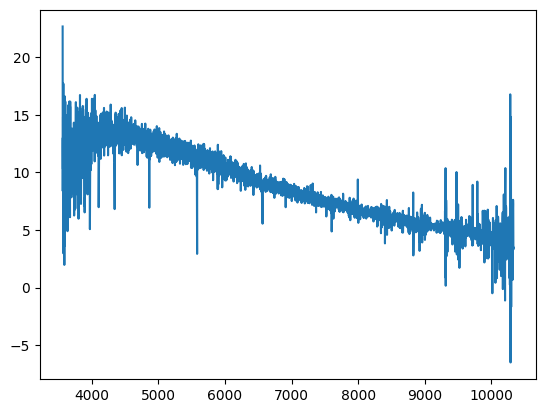

In [19]:
wavelength_grid = [10 ** row[1] for row in secondary_data]
flux = [row[0] for row in secondary_data]

plt.plot(wavelength_grid, flux)

In [3]:
SDSS.TIMEOUT = 300

### Fetching the spectral data

In [ ]:
class DataFetcher:

    '''
    Fetch stellar spectral data using SQL queries from SDSS sql sky server \n
    Object Attributes : \n
    spectral_class : string - from list ["O","B","F","K","M","A","G"] \n
    output_directory : string - saving directory
    '''

    def __init__(self, spectral_class, output_directory = "/kaggle/working"):
        self.spectral_class = spectral_class
        self.output_directory = output_directory

    def get_table(self):

        '''
        Request Query based on the spectral class
        '''

        if self.spectral_class == "F":
            num = 4290
        else:
            num = 4285

        # running the sql query to get the fiberid, mjd, plate for the stars
        sql_query = f'''SELECT TOP {num}
            specobjid, ra, dec,plate, mjd, fiberid, subclass, z, elodieTeff, elodieLogG, elodieFeH
            FROM SpecObj
            WHERE class = 'STAR' AND zWarning = 0 
              AND subclass LIKE '{self.spectral_class}%'
              AND (snMedian_u + snMedian_g + snMedian_r + snMedian_i + snMedian_z)/5.0 > 10
              AND elodieTeff IS NOT NULL AND elodieLogG IS NOT NULL AND elodieFeH IS NOT NULL'''

        res = SDSS.query_sql(sql_query, timeout = 600)

        return res

    # Defining a class method
    @classmethod
    def retrieve_spectra(cls, output_dir, row, failed_ids, chunk_num, n, spectral_class):
    
        save_dir = os.path.join(
            output_dir,
            f"flux_array_{spectral_class}",
            "spectrum_fits",
            f"Chunk_{chunk_num}"
        )
        os.makedirs(save_dir, exist_ok=True)
    
        save_path = os.path.join(save_dir, f"spectrum_{n}.npy")
    
        # 🔹 Resume capability: skip if already downloaded
        if os.path.exists(save_path):
            return
    
        plate = int(row["plate"])
        mjd = int(row["mjd"])
        fiber_id = int(row["fiberid"])
    
        for attempt in range(5):  # keep your retry depth
    
            try:
                SDSS.TIMEOUT = 300  # keep extended timeout
    
                spectra = SDSS.get_spectra(
                    plate=plate,
                    mjd=mjd,
                    fiberID=fiber_id,
                    data_release=19
                )

                if spectra is None:
                    print(f"No spectrum found for plate={plate}, mjd={mjd}, fiber={fiber_id}")
                    failed_ids.append((plate, mjd, fiber_id))
                    return
    
                # --- FITS extraction ---
                data_file = spectra[0]
                secondary_data = data_file[1].data
    
                flux = np.array([row_i[0] for row_i in secondary_data], dtype=float)
                loglam = np.array([row_i[1] for row_i in secondary_data], dtype=float)
                wavelength = 10 ** loglam
    
                star_data = {
                    "plate": plate,
                    "mjd": mjd,
                    "fiberid": fiber_id,
                    "specobjid": str(row["specobjid"]),
                    "spectral_class": str(row["subclass"]),
                    "teff": float(row["elodieTeff"]),
                    "logg": float(row["elodieLogG"]),
                    "feh": float(row["elodieFeH"]),
                    "flux": flux,
                    "wavelength": wavelength
                }
    
                np.save(save_path, star_data, allow_pickle=True)
    
                # small delay to avoid hammering SDSS
                time.sleep(0.5)
    
                return  # success → exit function
    
            # 🔹 Your original exponential backoff block (kept intact)
            except (ConnectionError, Timeout, ReadTimeout, socket.timeout,
                    RemoteDisconnected, ProtocolError, TimeoutError,
                   InconsistentTableError) as e:
    
                wait_time = 10 * (2 ** attempt) + random.uniform(0, 5)
                print(
                    f"{type(e).__name__}: Retry {attempt+1}/5 "
                    f"after {wait_time:.1f}s "
                    f"for plate={plate}, mjd={mjd}, fiber={fiber_id}"
                )
                time.sleep(wait_time)
    
        # 🔹 If all attempts fail
        
        failed_ids.append((plate, mjd, fiber_id))

    # chunk wise loading spectra
    def chunk_wise_loader(self, chunk_size,output_directory):
        ''' 
        Chunk wise loading the spectra for the given spectral class\n
        Parameters : \n
        chunk_size : int \n
        output_directory : string \n
        '''
        res = self.get_table()
        print(len(res))

        flux_array = []
        spectral_class = self.spectral_class
        
        n = len(res)//chunk_size   # n chunks
        count = 0
        for i in tqdm(range(n)):
            try:
                new_res = res[chunk_size * i : chunk_size * (i + 1)]
            except:
                new_res = res[chunk_size * i :]     # last chunk exception
            spectra_list = []
            failed_ids = []
            
            for j in range(chunk_size):  # loading inside a chunk
                row = new_res[j]
                DataFetcher.retrieve_spectra(output_directory, row, failed_ids, i,j, spectral_class)

                # checker block

    # consolidating the fetched data
    def consolidate_data(self):
        '''
        Consolidating all the npy spectra flux arrays
        '''
        input_directory = "/kaggle/input/sdss-dissertation-data-1"
        directory_path = f"{input_directory}/flux_array_{self.spectral_class}/spectrum_fits"
        
        chunk_list_dir = os.listdir(directory_path)
        spectra_list = []
        
        for chunk_dir in tqdm(chunk_list_dir):
            chunk_spectra_list_dir = os.listdir(f"{directory_path}/{chunk_dir}")
        
            for j in chunk_spectra_list_dir:
                spectra = np.load(f"{directory_path}/{chunk_dir}/{j}")
                spectra_list.append(spectra)

        np.save(f"{self.output_directory}/spectra_{self.spectral_class}", np.array(spectra_list, dtype = object))


In [ ]:
# spectral_class_list = ["A","F","G","K","M","O","B"]

# for i in spectral_class_list:
#     spectra_object= DataFetcher(spectral_class = i)
#     spectra_object.chunk_wise_loader(chunk_size = 200 if spectra_object.spectral_class in ["O", "B"] else 500, output_directory = "/kaggle/working")

In [ ]:
# spectra_class_list = ["O","B","A","F","G","K","M"]     

# for i in spectra_class_list:
#     spectra_object = DataFetcher(spectral_class = i)
#     spectra_object.consolidate_data()

ModuleNotFoundError: No module named 'astroquery.lamost'